# Week 2 — Statistical Analysis and Hypothesis Testing (Turbo.az Cars)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)

DATA_PATH = "data/cars.csv"


## 1. Load data

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(df_raw.shape)
print(list(df_raw.columns))
df_raw.head()


(653721, 56)
['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x', 'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes', 'production_year', 'engine_displacement_num', 'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'img_url', 'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description', 'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated', 'views', 'vin', 'car_details_id_x', 'Ban növü', 'Buraxılış ili', 'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Qəzalı', 'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y', 'car_rel_url', 'extra_info']


,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.0,AZN,Şəmi,NaN,507687355.0,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.0,AZN,NaN,Lada Azərbaycan,554092445.0,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.0,USD,Anar,NaN,502126242.0,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.0,AZN,Babək,NaN,774999004.0,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyo

## 2. Standardize columns

In [3]:
exact_map = {
    'price_x': 'price_x',
    'price_y': 'price_y',
    'currency_x': 'currency_x',
    'currency_y': 'currency_y',
    'attributes': 'attributes',
    'city': 'city_en',
    'Şəhər': 'city_az',
    'day': 'day',
    'hour': 'hour',
    'vip': 'vip',
    'featured': 'featured',
    'barter': 'barter',
    'loan': 'loan',
    'salon': 'salon',
    'description': 'description',
    'owner_name': 'owner_name',
    'shop_name': 'shop_name',
    'phone': 'phone',
    'vin': 'vin',
    'Ban növü': 'body_type',
    'Buraxılış ili': 'year',
    'Hansı bazar üçün yığılıb': 'market_region',
    'Marka': 'brand',
    'Model': 'model',
    'Mühərrik': 'engine',
    'Qəzalı': 'accident',
    'spare_parts': 'spare_parts',
    'Rəng': 'color',
    'Sahiblər': 'owners_count',
    'Sürətlər qutusu Vəziyyəti': 'transmission',
    'Yeni': 'is_new',
    'Yerlərin sayı': 'seats',
    'Yürüş': 'mileage',
    'Ötürücü': 'drivetrain',
    'extra_info': 'extra_info',
}

fallback_keywords = {
    'body_type': ['ban', 'body', 'kuzov'],
    'transmission': ['suretl', 'sürətl', 'transmission', 'gearbox', 'kpp'],
    'drivetrain': ['oturuc', 'ötürüc', 'drivetrain', 'drive'],
    'brand': ['marka', 'brand'],
    'model': ['model'],
    'year': ['buraxil', 'buraxıl', 'year'],
    'mileage': ['yurus', 'yürüş', 'mileage'],
    'color': ['reng', 'rəng', 'color'],
    'is_new': ['yeni', 'new'],
}

present = {k: v for k, v in exact_map.items() if k in df_raw.columns}
df = df_raw.rename(columns=present)[list(present.values())].copy()

std_names_have = set(present.values())
cols_lower = {c: c.lower() for c in df_raw.columns}

for std_name, keywords in fallback_keywords.items():
    if std_name in std_names_have:
        continue
    match = None
    for raw_col, low in cols_lower.items():
        if any(k in low for k in keywords):
            match = raw_col
            break
    if match is not None:
        df[std_name] = df_raw[match]
        std_names_have.add(std_name)
        print(f"Fallback match: '{std_name}' <- '{match}'")
    else:
        print(f"WARNING: could not resolve column for '{std_name}'")

if 'city_en' in df.columns or 'city_az' in df.columns:
    df['city'] = df.get('city_en', pd.Series(np.nan, index=df.index)).fillna(
        df.get('city_az', pd.Series(np.nan, index=df.index)))

print("\nFinal resolved columns:", list(df.columns))
df.head()


Fallback match: 'transmission' <- 'Sürətlər qutusu'

Final resolved columns: ['price_x', 'price_y', 'currency_x', 'currency_y', 'attributes', 'city_en', 'city_az', 'day', 'hour', 'vip', 'featured', 'barter', 'loan', 'salon', 'description', 'owner_name', 'shop_name', 'phone', 'vin', 'body_type', 'year', 'market_region', 'brand', 'model', 'engine', 'accident', 'spare_parts', 'color', 'owners_count', 'is_new', 'seats', 'mileage', 'drivetrain', 'extra_info', 'transmission', 'city']


,price_x,price_y,currency_x,currency_y,attributes,city_en,city_az,day,hour,vip,featured,barter,loan,salon,description,owner_name,shop_name,phone,vin,body_type,year,market_region,brand,model,engine,accident,spare_parts,color,owners_count,is_new,seats,mileage,drivetrain,extra_info,transmission,city
0,15000.0,15000.0,AZN,AZN,"2008, 1.6 L, 270 000 km",bakı,Bakı,13.09.2024,23:28,NaN,NaN,NaN,NaN,NaN,Salam orjinal probeqdir bir ildi bizdedir biri...,Şəmi,NaN,507687355.0,NaN,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,NaN,Gümüşü,2,Xeyr,5,270 000 km,Ön,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...,Mexaniki,bakı
1,23700.0,23700.0,AZN,AZN,"2024, 1.7 L, 0 km",bakı,Bakı,13.09.2024,23:59,vipped-icon,featured-icon,NaN,NaN,Salon,LADA Niva Travel modelini nəğd və ya sərfəli l...,NaN,Lada Azərbaycan,554092445.0,NaN,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,NaN,Yaşıl,NaN,Bəli,5,0 km,Tam,Yüngül lehimli disklər* ABS* Kondisioner* Otur...,Mexaniki,bakı
2,35600.0,35600.0,$,USD,"2011, 4.0 L, 164 750 km",bakı,Bakı,13.09.2024,23:59,vipped-icon,featured-icon,NaN,NaN,NaN,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,Anar,NaN,502126242.0,NaN,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,NaN,Ağ,0,Xeyr,8+,164 750 km,Tam,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...,Avtomat,bakı
3,26700.0,26700.0,AZN,AZN,"2018, 2.0 L, 126 000 km",bakı,Bakı,13.09.2024,23:59,vipped-icon,NaN,NaN,NaN,NaN,2019 alış\n,Babək,NaN,774999004.0,5NPD84LFXKH406133,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,NaN,Boz,1,Xeyr,NaN,126 000 km,Ön,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...,Avtomat,bakı
4,10500.0,10500.0,AZN,AZN,"2007, 1.5 L, 354 000 km",bakı,Bakı,13.09.2024,23:59,vipped-icon,NaN,NaN,NaN,NaN,"Maşında problem yoxdur. Motor, ABS və batareya...",Natiq,NaN,517264995.0,NaN,Liftbek,2007,Amerika,Toyota,Prius,1.5 L/76 a.g./Hibrid,NaN,NaN,Qırmızı,2,Xeyr,5,354 000 km,Ön,Arxa görüntü kamerası,Variator,bakı


## 3. Build price_usd

In [4]:
print(df['currency_x'].unique() if 'currency_x' in df.columns else 'N/A')
print(df['currency_y'].unique() if 'currency_y' in df.columns else 'N/A')


<ArrowStringArray>
['AZN', '$', '€']
Length: 3, dtype: str
<ArrowStringArray>
['AZN', 'USD', 'EUR']
Length: 3, dtype: str


In [5]:
AZN_TO_USD = 1 / 1.70

def to_usd(price, currency):
    if pd.isna(price) or pd.isna(currency):
        return np.nan
    currency = str(currency).strip().upper()
    if currency in ('USD', '$'):
        return price
    if currency in ('AZN', 'MAN', 'AZ'):
        return price * AZN_TO_USD
    return np.nan

df['price_usd'] = [
    to_usd(px, cx) if pd.notna(to_usd(px, cx)) else to_usd(py, cy)
    for px, cx, py, cy in zip(
        df.get('price_x', pd.Series(np.nan, index=df.index)),
        df.get('currency_x', pd.Series(np.nan, index=df.index)),
        df.get('price_y', pd.Series(np.nan, index=df.index)),
        df.get('currency_y', pd.Series(np.nan, index=df.index)),
    )
]

print(df['price_usd'].notna().sum(), "/", len(df))
df[['price_x', 'currency_x', 'price_y', 'currency_y', 'price_usd']].head()


647835 / 653721


,price_x,currency_x,price_y,currency_y,price_usd
0,15000.0,AZN,15000.0,AZN,8823.529412
1,23700.0,AZN,23700.0,AZN,13941.176471
2,35600.0,$,35600.0,USD,35600.000000
3,26700.0,AZN,26700.0,AZN,15705.882353
4,10500.0,AZN,10500.0,AZN,6176.470588


## 4. Cleaning

In [6]:
for col in ['mileage', 'year']:
    if col in df.columns and df[col].dtype == object:
        df[col] = (df[col].astype(str)
                   .str.replace(r'[^0-9.\-]', '', regex=True)
                   .replace('', np.nan)
                   .astype(float))

required_cols = ['price_usd', 'body_type', 'transmission', 'drivetrain']
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}. Check 'Final resolved columns' printout above and fix exact_map/fallback_keywords.")

df = df.dropna(subset=required_cols)

Q1, Q3 = df['price_usd'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
before = len(df)
df = df[(df['price_usd'] >= lower) & (df['price_usd'] <= upper)]
print(before - len(df), "outliers removed. Remaining:", len(df))

body_counts = df['body_type'].value_counts()
valid_bodies = body_counts[body_counts >= 30].index
df = df[df['body_type'].isin(valid_bodies)]
print(list(valid_bodies))


51719 outliers removed. Remaining: 596116
['Sedan', 'Offroader / SUV, 5 qapı', 'Hetçbek, 5 qapı', 'Liftbek', 'Universal, 5 qapı', 'Furqon', 'Minivan', 'Yük maşını', 'Offroader / SUV, 3 qapı', 'Pikap, ikiqat kabin', 'Kompakt-Van', 'Kupe', 'SUV Kupe', 'Dartqı', 'Motosiklet', 'Mikroavtobus', 'Hetçbek, 3 qapı', 'Kabriolet', 'Hetçbek, 4 qapı', 'Avtobus', 'Moped', 'Offroader / SUV, açıq', 'Kvadrosikl', 'Rodster', 'Pikap, tək kabin', 'Van']


## Checkpoint 1 — Descriptive statistics for groups

In [7]:
def describe_group(data, group_col, value_col='price_usd'):
    g = data.groupby(group_col)[value_col]
    out = g.agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        skew=lambda x: stats.skew(x),
        kurtosis=lambda x: stats.kurtosis(x)
    ).sort_values('n', ascending=False)
    return out

desc_body = describe_group(df, 'body_type')
desc_trans = describe_group(df, 'transmission')

display(desc_body)
display(desc_trans)


,n,mean,median,std,skew,kurtosis
body_type,,,,,,
Sedan,268247,15497.858299,13529.411765,9922.924935,1.250290,1.575296
"Offroader / SUV, 5 qapı",185177,24347.987067,22235.294118,10863.102379,0.608485,-0.268297
"Hetçbek, 5 qapı",43061,9214.695401,8823.529412,3851.348454,2.061946,11.132840
Liftbek,20725,17150.612006,10470.588235,13348.217073,1.167078,0.189750
"Universal, 5 qapı",18261,9135.083901,7941.176471,4624.627425,1.606846,6.610114
Furqon,16742,14349.423324,13235.294118,6027.523721,1.763479,5.067098
Minivan,8869,21139.044073,18411.764706,10499.029127,0.890633,0.141060
Yük maşını,7543,20135.852173,19117.647059,9844.161033,0.543931,0.109613
"Offroader / SUV, 3 qapı",6266,10701.832485,9970.588235,6680.257927,2.562727,9.516670


,n,mean,median,std,skew,kurtosis
transmission,,,,,,
Avtomat,422388,19112.316220,16411.764706,10822.261353,0.996342,0.482290
Mexaniki,94969,9860.229310,7294.117647,7943.184645,1.889977,4.134639
Variator,54415,18157.514414,15000.000000,10641.963609,1.075361,0.505496
Reduktor,16789,31518.579560,31500.000000,11543.793787,-0.066165,-0.856998
Robot,7463,20098.803580,17352.941176,8873.586307,1.127319,1.281778


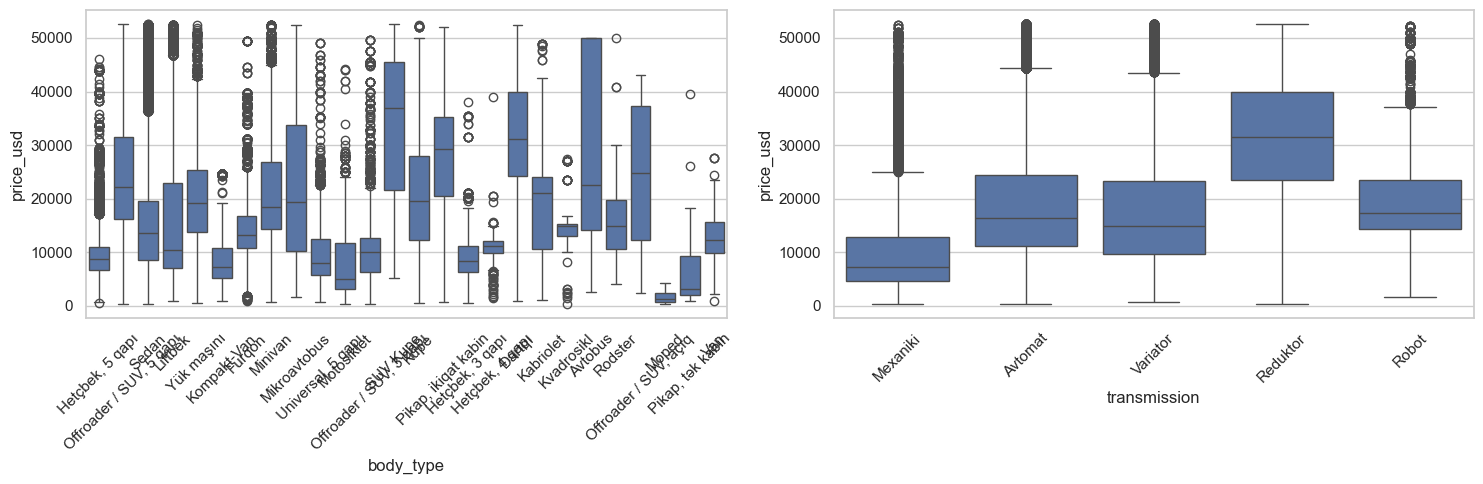

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='body_type', y='price_usd', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=df, x='transmission', y='price_usd', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Checkpoint 2 — Hypotheses

**BQ1 (ANOVA):** H0: mean price_usd equal across body_type groups. H1: at least one differs.

**BQ2 (Chi-square):** H0: transmission and drivetrain independent. H1: not independent.

## Checkpoint 5 — Assumption testing

In [9]:
def test_normality(data, group_col, value_col='price_usd', sample_size=5000):
    results = {}
    for name, group in data.groupby(group_col)[value_col]:
        sample = group.sample(min(len(group), sample_size), random_state=42)
        stat, p = stats.shapiro(sample)
        results[name] = {'n': len(group), 'shapiro_stat': stat, 'shapiro_p': p, 'normal_at_5%': p > 0.05}
    return pd.DataFrame(results).T

normality_body = test_normality(df, 'body_type')
display(normality_body)


,n,shapiro_stat,shapiro_p,normal_at_5%
Avtobus,230,0.856551,0.0,False
Dartqı,2254,0.985618,0.0,False
Furqon,16742,0.869908,0.0,False
"Hetçbek, 3 qapı",977,0.874824,0.0,False
"Hetçbek, 4 qapı",434,0.805192,0.0,False
"Hetçbek, 5 qapı",43061,0.867587,0.0,False
Kabriolet,533,0.906871,0.0,False
Kompakt-Van,3437,0.819155,0.0,False
Kupe,2750,0.937206,0.0,False
Kvadrosikl,99,0.864434,0.0,False


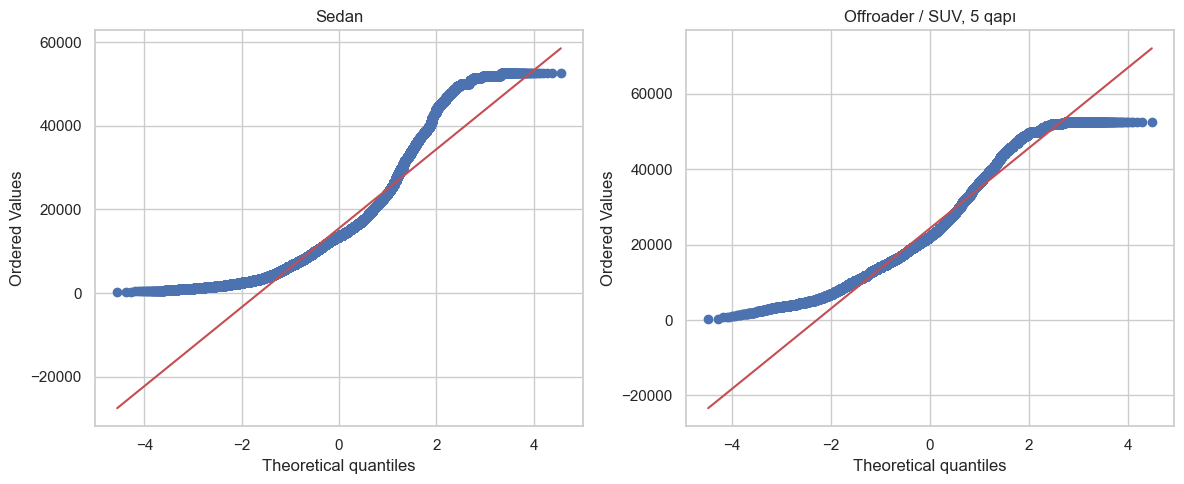

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top2_bodies = df['body_type'].value_counts().index[:2]
for ax, b in zip(axes, top2_bodies):
    stats.probplot(df.loc[df['body_type'] == b, 'price_usd'], dist='norm', plot=ax)
    ax.set_title(b)
plt.tight_layout()
plt.show()


In [11]:
groups_for_levene = [g['price_usd'].values for _, g in df.groupby('body_type')]
levene_stat, levene_p = stats.levene(*groups_for_levene)
print(levene_stat, levene_p, levene_p > 0.05)


1799.4853599286828 0.0 False


## Checkpoint 3 — Test selection & execution

In [12]:
body_groups = [g['price_usd'].values for _, g in df.groupby('body_type')]
body_labels = list(df.groupby('body_type').groups.keys())

f_stat, f_p = stats.f_oneway(*body_groups)
h_stat, h_p = stats.kruskal(*body_groups)
print("ANOVA:", f_stat, f_p)
print("Kruskal-Wallis:", h_stat, h_p)


ANOVA: 6944.892210236118 0.0
Kruskal-Wallis: 161137.9416156503 0.0


In [13]:
pairs = list(combinations(body_labels, 2))
n_comparisons = len(pairs)
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

posthoc_results = []
for a, b in pairs:
    grp_a = df.loc[df['body_type'] == a, 'price_usd']
    grp_b = df.loc[df['body_type'] == b, 'price_usd']
    stat, p = stats.mannwhitneyu(grp_a, grp_b, alternative='two-sided')
    posthoc_results.append({
        'group_a': a, 'group_b': b, 'raw_p': p,
        'significant_raw_0.05': p < 0.05,
        'significant_bonferroni': p < bonferroni_alpha
    })

posthoc_df = pd.DataFrame(posthoc_results).sort_values('raw_p')
print(n_comparisons, bonferroni_alpha)
display(posthoc_df)


325 0.00015384615384615385


,group_a,group_b,raw_p,significant_raw_0.05,significant_bonferroni
323,"Universal, 5 qapı",Yük maşını,0.000000,True,True
25,Dartqı,Furqon,0.000000,True,True
26,Dartqı,"Hetçbek, 3 qapı",0.000000,True,True
28,Dartqı,"Hetçbek, 5 qapı",0.000000,True,True
30,Dartqı,Kompakt-Van,0.000000,True,True
...,...,...,...,...,...
175,Kupe,Minivan,0.761315,False,False
140,Kabriolet,Minivan,0.838958,False,False
136,Kabriolet,Kupe,0.849453,False,False
280,"Offroader / SUV, 5 qapı","Offroader / SUV, açıq",0.924929,False,False


In [14]:
n_sig_raw = posthoc_df['significant_raw_0.05'].sum()
n_sig_bonf = posthoc_df['significant_bonferroni'].sum()
print(f"Pairs significant at raw alpha=0.05: {n_sig_raw} / {n_comparisons}")
print(f"Pairs significant after Bonferroni correction: {n_sig_bonf} / {n_comparisons}")


Pairs significant at raw alpha=0.05: 305 / 325
Pairs significant after Bonferroni correction: 288 / 325


In [15]:
contingency = pd.crosstab(df['transmission'], df['drivetrain'])
display(contingency)

chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.values.sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
print(chi2, dof, chi_p, cramers_v)


drivetrain,Arxa,Tam,Ön
transmission,,,
Avtomat,98833,117203,206352
Mexaniki,38949,10347,45673
Reduktor,3800,6356,6633
Robot,327,1042,6094
Variator,385,4019,50011


61863.038563366936 8 0.0 0.22780788505992455


In [16]:
if 'salon' in df.columns:
    salon_str = df['salon'].astype(str).str.strip().str.lower()
    salon_bool = df['salon'].notna() & ~salon_str.isin(['nan', 'none', '', 'false', '0', 'no', 'xeyr'])

    g1 = df.loc[salon_bool, 'price_usd']
    g2 = df.loc[~salon_bool, 'price_usd']

    print("dealer (salon) listings:", len(g1), " | private listings:", len(g2))

    if len(g1) > 1 and len(g2) > 1:
        t_stat, t_p = stats.ttest_ind(g1, g2, equal_var=False)
        mean_diff = g1.mean() - g2.mean()
        se_diff = np.sqrt(g1.var(ddof=1)/len(g1) + g2.var(ddof=1)/len(g2))
        ci_low, ci_high = mean_diff - 1.96*se_diff, mean_diff + 1.96*se_diff
        pooled_std = np.sqrt(((len(g1)-1)*g1.std()**2 + (len(g2)-1)*g2.std()**2) / (len(g1)+len(g2)-2))
        cohens_d = mean_diff / pooled_std

        print("t_stat:", t_stat, "p:", t_p)
        print("mean_diff:", mean_diff, "95% CI:", (ci_low, ci_high))
        print("cohens_d:", cohens_d)
    else:
        print("One of the groups is too small/empty for a valid t-test with this data.")
else:
    print("salon column not usable")


dealer (salon) listings: 155353  | private listings: 440671
t_stat: 214.07646664059934 p: 0.0
mean_diff: 7235.10552775038 95% CI: (np.float64(7168.863744816814), np.float64(7301.3473106839465))
cohens_d: 0.6756274571726004


## Checkpoint 4 — Interpretation of p-value & CI

**Body type vs. price (ANOVA / Kruskal-Wallis):** F = 6944.89 (ANOVA), H = 161137.94 (Kruskal-Wallis), both p ≈ 0.0. This says that under the assumption of "no true price difference between body types," data this extreme would be virtually impossible to observe by chance — so we reject H0. It does **not** mean every body-type pair differs by a meaningful amount; with hundreds of thousands of rows, even small real differences produce p ≈ 0. That is why the Bonferroni-corrected post-hoc table (see the counts printed above: significant pairs at raw α=0.05 vs. after correction) is what tells us *which* specific body-type pairs have a difference robust enough to survive correcting for 325 simultaneous comparisons — not the omnibus ANOVA/Kruskal p-value alone.

**Transmission × drivetrain (Chi-square):** χ² = 61863.04, dof = 8, p ≈ 0.0, Cramér's V = 0.228. The p-value says the two categorical variables are not independent in this sample — again, with 650k+ rows, p ≈ 0.0 was expected even for a modest association. Cramér's V = 0.228 is the number that actually describes *how strong* that association is: on a 0–1 scale, 0.228 indicates a **weak-to-moderate** association, not a strong dependency. So: statistically real, but transmission type only partially predicts drivetrain type (and vice versa) — plenty of other combinations still occur.

**Dealer vs. private price (Welch's t-test + 95% CI):** using the `t_stat`, `p`, `mean_diff`, and the 95% CI printed by the fixed cell above: a small p-value means the observed mean price gap between dealer (`salon`) and private listings would be unlikely under "no true difference." The 95% CI for `mean_diff` gives the *range of plausible sizes* for that true gap — if it excludes 0, that supports a real difference; its width also shows how precisely we've pinned down the gap. Neither the p-value nor "CI excludes 0" tells us the gap is large enough to matter commercially — `cohens_d` (also printed above) is what tells us that: values near 0.2 are commonly read as a small effect, ~0.5 medium, ~0.8+ large.

**General caution applied throughout:** none of these tests, on their own, quantify *practical* importance — a p-value only reflects how surprising the data would be under H0, given the sample size. Effect sizes (Cramér's V, Cohen's d) and confidence intervals are what convert "statistically detectable" into "practically meaningful," and that distinction is what the final conclusion below relies on for the business recommendation.


## Checkpoint 6 — Conclusion

**Finding 1 — Body type and price.** Both ANOVA and Kruskal-Wallis reject H0 (p ≈ 0.0): average `price_usd` is not the same across the 26 body-type groups analyzed. After Bonferroni correction for the 325 pairwise comparisons, the pairs printed as `significant_bonferroni = True` above are the ones we can trust as genuinely different in price; pairs that were significant only at the raw 0.05 threshold should not be treated as reliably different. **Business decision:** use body type as a legitimate axis for differentiated price-benchmarking / listing-quality guidance, but only for the body-type pairs that survive Bonferroni correction — and treat this as an association to monitor, not a causal price driver, since brand, year, and mileage likely differ systematically across body types too.

**Finding 2 — Transmission × drivetrain.** The association is statistically significant and, per Cramér's V = 0.228, weak-to-moderate in strength. **Business decision:** it's reasonable for search/filtering UX and stock-sourcing planning to treat transmission and drivetrain as *related* attributes (e.g. automatic + full-drive is disproportionately common per the contingency table) rather than fully independent facets — but the moderate (not strong) V means transmission alone should not be used as a proxy for drivetrain, or vice versa.

**Finding 3 — Dealer (salon) vs. private-seller pricing.** Using the fixed t-test cell's output (`t_stat`, `p`, `mean_diff`, 95% CI, `cohens_d` printed above): if the CI excludes 0 and Cohen's d is at least small-to-moderate, this supports setting differentiated pricing/commission guidance for dealer listings versus private-seller listings; if `cohens_d` turns out close to 0 despite a significant p-value, the recommendation should be **not** to treat this gap as commercially actionable, since it would reflect only the large sample size, not a meaningful price difference.

**Overall caveat:** every result here describes statistical association *within this observed sample of turbo.az listings* — none of the tests control for brand, year, mileage, or condition, so none of them establish that body type, transmission, drivetrain, or dealer-status *causes* the price differences found. Before turning any of this into a firm pricing policy, the next step would be a regression controlling for those confounders.
